<a href="https://colab.research.google.com/github/Peeyusj/week20_embeddings/blob/main/week20_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
model=SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
sentences = ["The doctor treated the patient",
"The nurse examined the patient",
"The mechanic fixed the engine",
"The carpenter built the table",
"A physician helped the sick person",
"The car engine was repaired"]
embeddings = model.encode(sentences)
print(embeddings)
print(embeddings.shape)

[[-0.03344362  0.12964527 -0.01536912 ...  0.03683927  0.08941578
   0.05191611]
 [-0.01975978  0.03082476 -0.08931582 ...  0.07430752  0.07273374
  -0.00828647]
 [-0.09965248  0.08228301  0.06101254 ...  0.05569614  0.079057
  -0.05055426]
 [-0.02166607  0.05073595 -0.03883024 ...  0.04239376 -0.00313739
   0.04810375]
 [ 0.01190977  0.12649287 -0.02746684 ...  0.03242917  0.03411439
   0.0618611 ]
 [-0.13460207  0.11210053  0.04254006 ...  0.06402815  0.06649085
  -0.00360161]]
(6, 384)


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix.shape)
print(similarity_matrix.round(2))

(6, 6)
[[1.   0.65 0.36 0.07 0.71 0.35]
 [0.65 1.   0.21 0.11 0.45 0.2 ]
 [0.36 0.21 1.   0.15 0.27 0.77]
 [0.07 0.11 0.15 1.   0.1  0.17]
 [0.71 0.45 0.27 0.1  1.   0.23]
 [0.35 0.2  0.77 0.17 0.23 1.  ]]


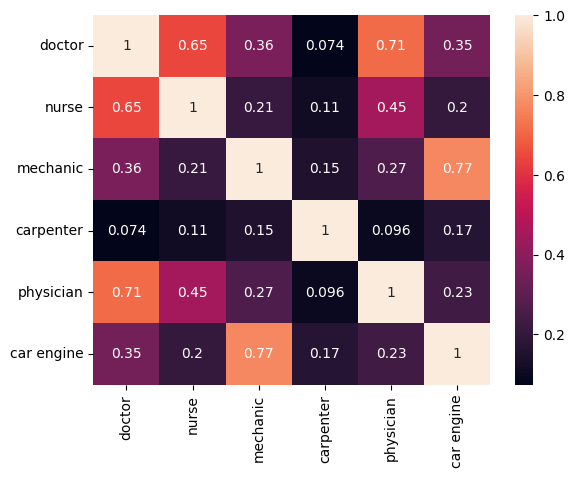

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["doctor", "nurse", "mechanic", "carpenter", "physician", "car engine"]
sns.heatmap(similarity_matrix, annot= True, xticklabels=labels, yticklabels=labels)
plt.show()